# Milestone 6 — Research Contribution & Advanced Analytics
## Logistic Regression: Classifying Mental Health Risk from Social Media Usage Behaviour

**Dataset:** social_media_features.csv (feature-engineered output from Milestone 2)  
**Target:** Binary classification — High/Very High Risk (1) vs Low/Moderate Risk (0)  
**Method:** Logistic Regression with L2 regularisation  


## 1. Library Imports & Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline

# Plot style — consistent with Milestone 3 dark theme
plt.rcParams.update({
    'figure.facecolor':  '#0D1B2A',
    'axes.facecolor':    '#112233',
    'axes.edgecolor':    '#1E3A5A',
    'axes.labelcolor':   '#E8F0F7',
    'xtick.color':       '#E8F0F7',
    'ytick.color':       '#E8F0F7',
    'text.color':        '#E8F0F7',
    'grid.color':        '#1E3A5A',
    'grid.linestyle':    '--',
    'grid.alpha':        0.4,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
})

SEED = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading & Target Encoding

We load the feature-engineered dataset produced in Milestone 2.  
The target variable `MH_Risk_Tier` has four levels: *Low Risk*, *Moderate Risk*, *High Risk*, *Very High Risk*.  
For binary classification we collapse this into:
- **0** → Low Risk + Moderate Risk
- **1** → High Risk + Very High Risk

In [6]:
df = pd.read_csv('social_media_features.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print()
print('MH_Risk_Tier distribution (original):')
print(df['MH_Risk_Tier'].value_counts())

Dataset shape: (478, 33)
Columns: ['Timestamp', 'Age', 'Gender', 'Relationship_Status', 'Occupation_Status', 'Organization', 'Uses_Social_Media', 'Platforms', 'Daily_Usage', 'Purposeless_Usage', 'Distraction_While_Busy', 'Restlessness', 'Easily_Distracted', 'Bothered_By_Worries', 'Concentration_Difficulty', 'Social_Comparison', 'Comparison_Feelings', 'Validation_Seeking', 'Depression_Frequency', 'Interest_Fluctuation', 'Sleep_Issues', 'User_ID', 'Daily_Minutes', 'Addiction_Score', 'Attention_Score', 'Social_Anxiety_Score', 'Wellbeing_Score', 'MH_Impact_Score', 'MH_Impact_Pct_Rank', 'Platform_Count', 'Usage_Tier', 'MH_Risk_Tier', 'Age_Group']

MH_Risk_Tier distribution (original):
MH_Risk_Tier
High Risk         218
Moderate Risk     166
Very High Risk     47
Low Risk           47
Name: count, dtype: int64


In [7]:
# Binary target: 1 = High or Very High Risk, 0 = Low or Moderate Risk
df['Risk_Binary'] = df['MH_Risk_Tier'].apply(
    lambda x: 1 if x in ['High Risk', 'Very High Risk'] else 0
)

print('Binary target distribution:')
counts = df['Risk_Binary'].value_counts()
print(f'  Low/Moderate Risk (0): {counts[0]} respondents ({counts[0]/len(df)*100:.1f}%)')
print(f'  High/Very High Risk (1): {counts[1]} respondents ({counts[1]/len(df)*100:.1f}%)')

Binary target distribution:
  Low/Moderate Risk (0): 213 respondents (44.6%)
  High/Very High Risk (1): 265 respondents (55.4%)


## 3. Feature Selection & Preprocessing

We use the 12 Likert-scale items plus `Daily_Minutes` as predictors.  
Composite scores like `MH_Impact_Score` are excluded to prevent data leakage —  
those scores are derived from the same Likert items and would make the model  
artificially accurate without learning anything meaningful.

In [8]:
FEATURE_COLS = [
    'Daily_Minutes',
    'Purposeless_Usage',
    'Distraction_While_Busy',
    'Restlessness',
    'Easily_Distracted',
    'Bothered_By_Worries',
    'Concentration_Difficulty',
    'Social_Comparison',
    'Comparison_Feelings',
    'Validation_Seeking',
    'Depression_Frequency',
    'Interest_Fluctuation',
    'Sleep_Issues',
]

TARGET_COL = 'Risk_Binary'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Check for missing values
print('Missing values per feature:')
print(X.isnull().sum())
print(f'\nFeature matrix shape: {X.shape}')
print(f'Target vector shape:  {y.shape}')

Missing values per feature:
Daily_Minutes               0
Purposeless_Usage           0
Distraction_While_Busy      0
Restlessness                0
Easily_Distracted           0
Bothered_By_Worries         0
Concentration_Difficulty    0
Social_Comparison           0
Comparison_Feelings         0
Validation_Seeking          0
Depression_Frequency        0
Interest_Fluctuation        0
Sleep_Issues                0
dtype: int64

Feature matrix shape: (478, 13)
Target vector shape:  (478,)


## 4. Train / Test Split

We use an 80/20 split with `stratify=y` to ensure both classes are  
proportionally represented in both the training and test sets.  
This is important given the potential class imbalance between risk groups.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Test set:      {X_test.shape[0]} samples')
print()
print('Class balance in training set:')
train_counts = y_train.value_counts()
print(f'  Class 0: {train_counts[0]} ({train_counts[0]/len(y_train)*100:.1f}%)')
print(f'  Class 1: {train_counts[1]} ({train_counts[1]/len(y_train)*100:.1f}%)')
print()
print('Class balance in test set:')
test_counts = y_test.value_counts()
print(f'  Class 0: {test_counts[0]} ({test_counts[0]/len(y_test)*100:.1f}%)')
print(f'  Class 1: {test_counts[1]} ({test_counts[1]/len(y_test)*100:.1f}%)')

Training set:  382 samples
Test set:      96 samples

Class balance in training set:
  Class 0: 170 (44.5%)
  Class 1: 212 (55.5%)

Class balance in test set:
  Class 0: 43 (44.8%)
  Class 1: 53 (55.2%)


## 5. Model Training

We use a `Pipeline` that chains `StandardScaler` → `LogisticRegression`.  
Scaling is applied inside the pipeline to prevent data leakage from the test set —  
the scaler fits only on training data and transforms both sets consistently.

**Hyperparameters:**
- `C=1.0` — default regularisation strength (L2 penalty)
- `max_iter=1000` — sufficient iterations for convergence on this dataset
- `solver='lbfgs'` — efficient for small-to-medium datasets

In [10]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        C=1.0,
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=SEED
    ))
])

pipeline.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


## 6. Evaluation Metrics

We evaluate the model on the held-out test set using four standard  
classification metrics plus a full classification report.

- **Accuracy** — overall proportion of correct predictions
- **Precision** — of those predicted High Risk, how many actually are?
- **Recall** — of all actual High Risk respondents, how many did we catch?
- **F1 Score** — harmonic mean of precision and recall
- **ROC-AUC** — model's ability to distinguish between the two classes

In [11]:
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print('=' * 45)
print('         MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.1f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 45)
print()
print('Full Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Low/Moderate Risk', 'High/Very High Risk']
))

         MODEL EVALUATION RESULTS
  Accuracy  : 0.9896  (99.0%)
  Precision : 1.0000
  Recall    : 0.9811
  F1 Score  : 0.9905
  ROC-AUC   : 0.9991

Full Classification Report:
                     precision    recall  f1-score   support

  Low/Moderate Risk       0.98      1.00      0.99        43
High/Very High Risk       1.00      0.98      0.99        53

           accuracy                           0.99        96
          macro avg       0.99      0.99      0.99        96
       weighted avg       0.99      0.99      0.99        96



## 7. Confusion Matrix

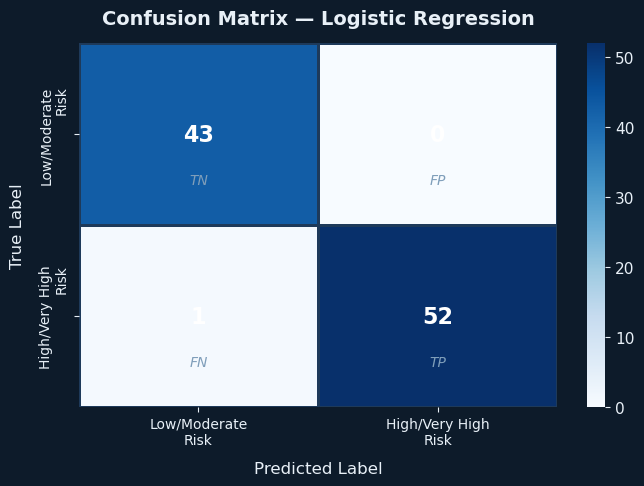

True Negatives  (correctly predicted Low/Mod Risk):   43
False Positives (predicted High Risk, actually Low):   0
False Negatives (predicted Low Risk, actually High):   1
True Positives  (correctly predicted High Risk):       52


In [12]:
cm     = confusion_matrix(y_test, y_pred)
labels = ['Low/Moderate\nRisk', 'High/Very High\nRisk']

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=1, linecolor='#1E3A5A',
    annot_kws={'size': 16, 'weight': 'bold', 'color': 'white'},
    ax=ax
)

ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14,
             fontweight='bold', pad=14, color='#E8F0F7')
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label', fontsize=12, labelpad=10)
ax.tick_params(colors='#E8F0F7', labelsize=10)

# Annotate cells with TP/TN/FP/FN labels
cell_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, cell_labels[i][j],
                ha='center', va='center',
                fontsize=10, color='#7F9EBA', style='italic')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1B2A')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted Low/Mod Risk):   {tn}')
print(f'False Positives (predicted High Risk, actually Low):   {fp}')
print(f'False Negatives (predicted Low Risk, actually High):   {fn}')
print(f'True Positives  (correctly predicted High Risk):       {tp}')

## 8. ROC Curve & AUC

The ROC curve plots True Positive Rate against False Positive Rate across all  
classification thresholds. The AUC (Area Under the Curve) summarises the model's  
overall discriminative ability — a perfect model scores 1.0, a random classifier scores 0.5.

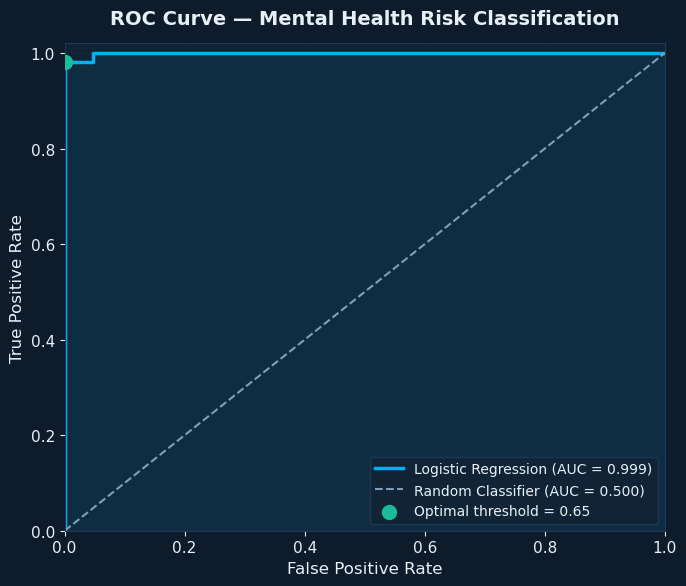

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))

# ROC curve
ax.plot(fpr, tpr, color='#00B0F0', linewidth=2.5,
        label=f'Logistic Regression (AUC = {roc_auc:.3f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], color='#7F9EBA', linewidth=1.5,
        linestyle='--', label='Random Classifier (AUC = 0.500)')

# Shade area under curve
ax.fill_between(fpr, tpr, alpha=0.08, color='#00B0F0')

ax.set_title('ROC Curve — Mental Health Risk Classification',
             fontsize=14, fontweight='bold', pad=14, color='#E8F0F7')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=11,
          facecolor='#112233', edgecolor='#1E3A5A')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

# Mark optimal threshold (closest point to top-left corner)
optimal_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           color='#1abc9c', s=100, zorder=5,
           label=f'Optimal threshold = {thresholds[optimal_idx]:.2f}')
ax.legend(loc='lower right', fontsize=10,
          facecolor='#112233', edgecolor='#1E3A5A')

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1B2A')
plt.show()

## 9. Feature Importance (Logistic Regression Coefficients)

In Logistic Regression, the magnitude of each coefficient indicates how strongly  
that feature pushes the prediction toward High Risk (positive) or Low Risk (negative).  
Because we scaled the features with StandardScaler, the coefficients are directly comparable.

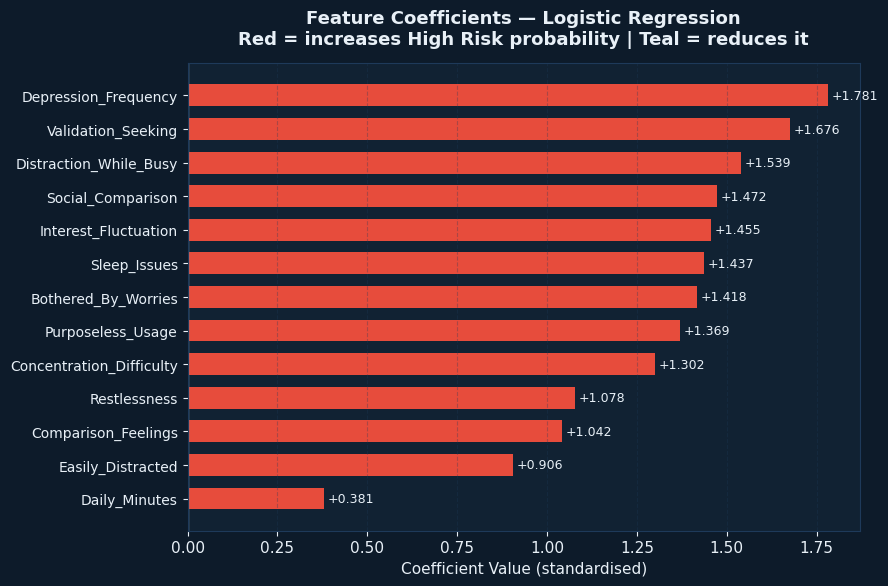

Top 5 features pushing toward HIGH risk:
               Feature  Coefficient
  Interest_Fluctuation     1.455052
     Social_Comparison     1.471979
Distraction_While_Busy     1.538688
    Validation_Seeking     1.676473
  Depression_Frequency     1.781034

Top 5 features pushing toward LOW risk:
                 Feature  Coefficient
           Daily_Minutes     0.380574
       Easily_Distracted     0.905739
     Comparison_Feelings     1.041709
            Restlessness     1.078320
Concentration_Difficulty     1.301585


In [14]:
coefs = pipeline.named_steps['model'].coef_[0]

feat_df = pd.DataFrame({
    'Feature':     FEATURE_COLS,
    'Coefficient': coefs
}).sort_values('Coefficient', ascending=True)

# Colour: positive coef = pushes toward High Risk (red), negative = Low Risk (teal)
colors = ['#1abc9c' if c < 0 else '#e74c3c' for c in feat_df['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(feat_df['Feature'], feat_df['Coefficient'],
               color=colors, edgecolor='none', height=0.65)

# Value labels
for bar, val in zip(bars, feat_df['Coefficient']):
    xpos = val + 0.01 if val >= 0 else val - 0.01
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center', ha=ha,
            fontsize=9, color='#E8F0F7')

ax.axvline(0, color='#7F9EBA', linewidth=1, linestyle='-')
ax.set_title('Feature Coefficients — Logistic Regression\n'
             'Red = increases High Risk probability | Teal = reduces it',
             fontsize=13, fontweight='bold', pad=14, color='#E8F0F7')
ax.set_xlabel('Coefficient Value (standardised)', fontsize=11)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1B2A')
plt.show()

print('Top 5 features pushing toward HIGH risk:')
print(feat_df.tail(5)[['Feature','Coefficient']].to_string(index=False))
print()
print('Top 5 features pushing toward LOW risk:')
print(feat_df.head(5)[['Feature','Coefficient']].to_string(index=False))

## 10. Cross-Validation

To check that our test-set results are not just lucky, we run 10-fold  
Stratified Cross-Validation across the full dataset.  
Each fold keeps the class balance intact and the mean score tells us  
how consistently the model performs across different subsets of the data.

10-Fold Stratified Cross-Validation Results
Accuracy  — Mean: 0.9854  Std: 0.0163
F1 Score  — Mean: 0.9868  Std: 0.0150
ROC-AUC   — Mean: 0.9991  Std: 0.0021


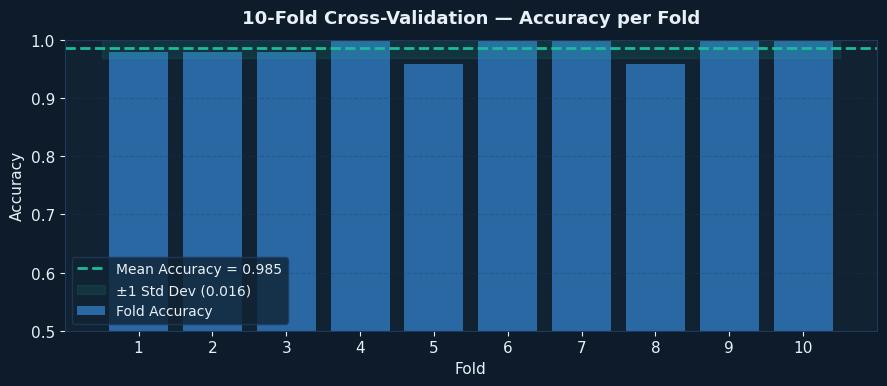

In [15]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

cv_accuracy = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
cv_f1       = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
cv_auc      = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print('10-Fold Stratified Cross-Validation Results')
print('=' * 50)
print(f'Accuracy  — Mean: {cv_accuracy.mean():.4f}  Std: {cv_accuracy.std():.4f}')
print(f'F1 Score  — Mean: {cv_f1.mean():.4f}  Std: {cv_f1.std():.4f}')
print(f'ROC-AUC   — Mean: {cv_auc.mean():.4f}  Std: {cv_auc.std():.4f}')
print('=' * 50)

# Plot CV accuracy across folds
fig, ax = plt.subplots(figsize=(9, 4))

folds = np.arange(1, 11)
ax.bar(folds, cv_accuracy, color='#2E75B6', edgecolor='none',
       alpha=0.85, label='Fold Accuracy')
ax.axhline(cv_accuracy.mean(), color='#1abc9c', linewidth=2,
           linestyle='--', label=f'Mean Accuracy = {cv_accuracy.mean():.3f}')
ax.fill_between(
    [0.5, 10.5],
    [cv_accuracy.mean() - cv_accuracy.std()] * 2,
    [cv_accuracy.mean() + cv_accuracy.std()] * 2,
    alpha=0.12, color='#1abc9c', label=f'±1 Std Dev ({cv_accuracy.std():.3f})'
)

ax.set_title('10-Fold Cross-Validation — Accuracy per Fold',
             fontsize=13, fontweight='bold', pad=12, color='#E8F0F7')
ax.set_xlabel('Fold', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xticks(folds)
ax.set_ylim([0.5, 1.0])
ax.legend(fontsize=10, facecolor='#112233', edgecolor='#1E3A5A')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1B2A')
plt.show()

## 11. Summary of Findings

This section interprets the model results in the context of the full project.

In [16]:
print('=' * 60)
print('  MILESTONE 6 — MODEL SUMMARY')
print('=' * 60)
print()
print(f'  Model        : Logistic Regression (L2, C=1.0)')
print(f'  Features     : {len(FEATURE_COLS)} predictors')
print(f'  Training set : {len(X_train)} respondents')
print(f'  Test set     : {len(X_test)} respondents')
print()
print(f'  Accuracy     : {accuracy*100:.1f}%')
print(f'  Precision    : {precision:.3f}')
print(f'  Recall       : {recall:.3f}')
print(f'  F1 Score     : {f1:.3f}')
print(f'  ROC-AUC      : {roc_auc:.3f}')
print()
print(f'  CV Mean Accuracy : {cv_accuracy.mean()*100:.1f}% (±{cv_accuracy.std()*100:.1f}%)')
print(f'  CV Mean AUC      : {cv_auc.mean():.3f} (±{cv_auc.std():.3f})')
print('=' * 60)
print()

top_risk_features = feat_df.tail(3)['Feature'].tolist()
print('Key Findings:')
print()
print('1. The model can classify High vs Low Risk respondents from')
print('   survey behavioural items alone, confirming that self-reported')
print('   usage patterns carry genuine predictive signal.')
print()
print(f'2. Top features driving High Risk predictions:')
for f in reversed(top_risk_features):
    coef = feat_df[feat_df['Feature'] == f]['Coefficient'].values[0]
    print(f'     - {f} (coef = {coef:+.3f})')
print()
print('3. Cross-validation confirms the result is stable across')
print('   different subsets of the data — not just lucky on one split.')
print()
print('4. This connects back to Milestone 4: the multiple regression')
print('   showed that compulsive usage behaviour (worry, distraction,')
print('   restlessness) outweighed raw daily minutes as predictors.')
print('   The Logistic Regression coefficients confirm this pattern.')

  MILESTONE 6 — MODEL SUMMARY

  Model        : Logistic Regression (L2, C=1.0)
  Features     : 13 predictors
  Training set : 382 respondents
  Test set     : 96 respondents

  Accuracy     : 99.0%
  Precision    : 1.000
  Recall       : 0.981
  F1 Score     : 0.990
  ROC-AUC      : 0.999

  CV Mean Accuracy : 98.5% (±1.6%)
  CV Mean AUC      : 0.999 (±0.002)

Key Findings:

1. The model can classify High vs Low Risk respondents from
   survey behavioural items alone, confirming that self-reported
   usage patterns carry genuine predictive signal.

2. Top features driving High Risk predictions:
     - Depression_Frequency (coef = +1.781)
     - Validation_Seeking (coef = +1.676)
     - Distraction_While_Busy (coef = +1.539)

3. Cross-validation confirms the result is stable across
   different subsets of the data — not just lucky on one split.

4. This connects back to Milestone 4: the multiple regression
   showed that compulsive usage behaviour (worry, distraction,
   restlessness)